In [113]:
import pandas as pd
import numpy as np
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.ensemble import BaggingClassifier
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\wineQualityReds.csv')

In [114]:
df['target'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)
df.drop(['Unnamed: 0', 'quality'], axis=1, inplace=True)

In [115]:
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

In [116]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print(metrics.f1_score(y_test, y_pred_log_reg))

0.7451737451737451


In [117]:
tree_1 = DecisionTreeClassifier(random_state=42, max_depth=10)
tree_1.fit(X_train, y_train)
y_pred_tree = tree_1.predict(X_test)
print(metrics.f1_score(y_test, y_pred_tree))


0.7927927927927928


In [118]:
BC = BaggingClassifier(tree_1, n_estimators=1500, random_state=42)
BC.fit(X_train, y_train)
y_pred_BC = BC.predict(X_test)
print(metrics.f1_score(y_test, y_pred_BC))

0.8181818181818182


In [130]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\boston (1).csv')

for i in ['crim_rate', 'business', 'nit_oxiden', 'rooms', 'age', 'dist', 'pup_per_teaс', 'lower', 'zn']:
    df[i] = df[i].apply(lambda x: np.float32((x.replace(',', '.'))))
df['target'] = df['target'].apply(lambda x: np.float64((x.replace(',', '.'))))
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=13)

In [132]:
y_train.mean()

22.77316384180791

In [127]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin_reg = lin_reg.predict(X_test)
print(metrics.mean_absolute_error(y_test, y_pred_lin_reg))

3.7222793342304468


In [128]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=13)
tree_reg.fit(X_train, y_train)
y_pred_tree_reg = tree_reg.predict(X_test)
print(metrics.mean_absolute_error(y_test, y_pred_tree_reg))

2.859210547647978


In [129]:
from sklearn.ensemble import RandomForestRegressor
for i in [3, 10, 100, 500]:
    ran = RandomForestRegressor(random_state=13, n_estimators=i)
    ran.fit(X_train, y_train)
    y_pred_ran = ran.predict(X_test)
    print(metrics.mean_absolute_error(y_test, y_pred_ran))


2.8745614541204354
2.4402632092174734
2.272697436244864
2.2452592737549226


In [252]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [253]:
df.isnull().sum().sum()

343248

In [254]:
df.dropna(thresh=0.6*len(df), axis=1, inplace=True)

In [255]:
df['RainToday'] = df['RainToday'].map({'No' : 0, 'Yes' : 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No' : 0, 'Yes' : 1})

In [256]:
np.mean(df['RainToday'])

0.22419285648984874

In [257]:
df['Date'] = pd.to_datetime(df['Date'])
df['Months'] = df['Date'].dt.month
df.drop('Date', axis=1, inplace=True)

In [258]:
df_group = df.groupby('Months').mean(numeric_only=True)
df_group['RainToday']

Months
1     0.189484
2     0.206746
3     0.217135
4     0.216845
5     0.222163
6     0.263638
7     0.270736
8     0.253167
9     0.229135
10    0.196512
11    0.210843
12    0.213037
Name: RainToday, dtype: float64

In [259]:
categoricals = ['Months', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
df_dum = pd.get_dummies(df, columns=categoricals)
df_dum.shape

(145460, 124)

In [260]:
df_dum.dropna(ignore_index=True, inplace=True)

In [261]:
X, y = df_dum.drop('RainTomorrow', axis=1), df_dum['RainTomorrow']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=31)
np.mean(y_test)

0.22770253002811142

In [262]:
X_train

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
12561,18.6,24.4,2.2,44.0,24.0,22.0,71.0,59.0,1024.4,1022.0,...,False,False,False,False,False,False,False,False,False,False
10755,17.7,20.4,1.9,89.0,50.0,48.0,91.0,94.0,1013.4,1009.3,...,False,False,False,False,False,False,False,False,False,False
75436,24.5,32.8,0.2,31.0,11.0,13.0,81.0,56.0,1010.4,1007.0,...,False,False,False,False,False,False,False,False,False,False
4961,13.6,20.2,1.0,44.0,26.0,20.0,66.0,81.0,1028.3,1027.9,...,False,False,False,False,False,True,False,False,False,False
74419,22.3,33.3,0.0,37.0,13.0,20.0,73.0,28.0,1014.9,1011.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,8.6,12.9,21.0,63.0,26.0,31.0,77.0,62.0,1004.0,1003.3,...,False,False,False,False,False,False,False,False,True,False
69271,18.9,40.9,0.0,33.0,20.0,15.0,19.0,12.0,1007.7,1005.2,...,False,False,False,False,False,False,False,True,False,False
27518,9.7,30.2,0.0,37.0,19.0,13.0,44.0,29.0,1022.7,1018.1,...,False,False,False,False,False,False,False,False,False,False
26640,4.3,17.1,0.0,31.0,17.0,11.0,86.0,61.0,1022.4,1018.7,...,False,False,False,False,False,False,False,False,True,False


In [271]:
np.random.seed(31)
n = 1000
n_samples = len(X_train)
random_indices = np.random.randint(0, n_samples, size=(n, n_samples))
min_temp_values = np.array(X_train.iloc[:, 0])
f = np.mean(min_temp_values[random_indices], axis=1)
print(np.std(f))

0.02879072820657669


In [ ]:
# log_reg = LogisticRegression(max_iter=1000)
# log_reg.fit(X_train, y_train)
# y_pred_log_reg = log_reg.predict(X_test)
# print(metrics.roc_auc_score(y_test, y_pred_log_reg))
#0.7348889351885897


0.7348889351885897


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Теперь попробуйте обучить на наших данных другой алгоритм — дерево решений. С помощью GridSearchCV сделайте перебор гиперпараметров по следующей сетке:

params = {'max_leaf_nodes': list(range(2, 10)), 'min_samples_split': [2, 3, 4], 'max_depth': [5,7,9,11]}
Для параметра кросс-валидации cv задайте значение 3. Для решающего дерева определите параметр random_state=42. Остальные параметры оставьте по умолчанию.

In [278]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
tree_2 = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=3)
params = {'max_leaf_nodes': list(range(2, 10)), 'min_samples_split': [2, 3, 4], 'max_depth': [5,7,9,11]}
grid = GridSearchCV(tree_2, param_grid=params, scoring='roc_auc', cv=3)
grid.fit(X_train, y_train)
grid

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [5, 7, ...], 'max_leaf_nodes': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [279]:
tree_best = grid.best_estimator_
y_pred_tree_best = tree_best.predict(X_test)
print(metrics.roc_auc_score(y_test, y_pred_tree_best))

0.7033229072349596


In [280]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=31)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
print(metrics.roc_auc_score(y_test, y_pred_rf))

0.7329684570290497


In [ ]:
grid_1 = GridSearchCV(estimator=random_forest, param_grid={'max_features': [4, 5, 6, 7], 'min_samples_leaf': [3, 5, 7, 9, 11], 'max_depth': [5, 10, 15]},
                      cv=3, scoring='roc_auc', verbose=10)
grid_1.fit(X_train, y_train)
grid_1

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3; 1/60] START max_depth=5, max_features=4, min_samples_leaf=3............
[CV 1/3; 1/60] END max_depth=5, max_features=4, min_samples_leaf=3;, score=0.839 total time=   1.5s
[CV 2/3; 1/60] START max_depth=5, max_features=4, min_samples_leaf=3............
[CV 2/3; 1/60] END max_depth=5, max_features=4, min_samples_leaf=3;, score=0.849 total time=   1.5s
[CV 3/3; 1/60] START max_depth=5, max_features=4, min_samples_leaf=3............
[CV 3/3; 1/60] END max_depth=5, max_features=4, min_samples_leaf=3;, score=0.843 total time=   1.5s
[CV 1/3; 2/60] START max_depth=5, max_features=4, min_samples_leaf=5............
[CV 1/3; 2/60] END max_depth=5, max_features=4, min_samples_leaf=5;, score=0.839 total time=   1.5s
[CV 2/3; 2/60] START max_depth=5, max_features=4, min_samples_leaf=5............
[CV 2/3; 2/60] END max_depth=5, max_features=4, min_samples_leaf=5;, score=0.848 total time=   1.5s
[CV 3/3; 2/60] START max_depth=5,

,estimator,RandomForestC...ndom_state=31)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': [4, 5, ...], 'min_samples_leaf': [3, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [284]:
random_forest_best = grid_1.best_estimator_
y_pred_rnb = random_forest_best.predict(X_test)
print(metrics.roc_auc_score(y_test, y_pred_rnb))

0.7005484843285417


In [293]:
imp = random_forest_best.feature_importances_
names = random_forest_best.feature_names_in_
data = pd.DataFrame({'Название' : names, 'Важность' : imp}).sort_values('Важность', ascending=False)
data.head(10)

,Название,Важность
7,Humidity3pm,0.250783
2,Rainfall,0.079757
6,Humidity9am,0.070403
10,Cloud9am,0.067092
9,Pressure3pm,0.065272
8,Pressure9am,0.061658
3,WindGustSpeed,0.056431
13,RainToday,0.047852
12,Temp3pm,0.043167
1,MaxTemp,0.035833


In [296]:
!pip install xgboost


In [297]:
!pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB 640.0 kB/s eta 0:02:41
   ---------------------------------------- 0.1/102.4 MB 656.4 kB/s eta 0:02:36
   ---------------------------------------- 0.1/102.4 MB 901.1 kB/s eta 0:01:54
   ---------------------------------------- 0.2/102.4 MB 1.1 MB/s eta 0:01:36
   ---------------------------------------- 0.2/102.4 MB 981.9 kB/s eta 0:01:45
   ---------------------------------------- 0.3/102.4 MB 1.2 MB/s eta 0:01:29
   ---------------------------------------- 0.4/102.4 MB 1.3 MB/s eta 0:01:18
   ---------------------------------------- 0.5/102.4 MB 1.4 MB/s eta 0:01:12
   ---------------------------------------- 0.6/102.4 MB 1.6 MB/s eta 0:01:03
   ---------------------------------------- 0.8/102.4 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 0.9/102.4 MB 1.8 MB/s eta 0:00:56
   ---------------------------------------- 1.1/102.4 MB 2.0 MB

In [312]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\AirPass.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)

In [313]:
df.isnull().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [314]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [315]:
np.mean(df['Arrival Delay in Minutes'])

15.133392362180475

In [321]:
df_group_sex = df.groupby('satisfaction')['Gender'].value_counts()/df.shape[0]
df_group_sex

satisfaction             Gender
neutral or dissatisfied  Female    0.290586
                         Male      0.276082
satisfied                Female    0.216873
                         Male      0.216459
Name: count, dtype: float64

In [326]:
df.groupby('Type of Travel')['satisfaction'].value_counts()/df.shape[0]

Type of Travel   satisfaction           
Business travel  satisfied                  0.401775
                 neutral or dissatisfied    0.287852
Personal Travel  neutral or dissatisfied    0.278815
                 satisfied                  0.031558
Name: count, dtype: float64

In [325]:
df.groupby('Class')['satisfaction'].value_counts()/df.shape[0]

Class     satisfaction           
Business  satisfied                  0.331845
          neutral or dissatisfied    0.146145
Eco       neutral or dissatisfied    0.366146
          satisfied                  0.083741
Eco Plus  neutral or dissatisfied    0.054377
          satisfied                  0.017747
Name: count, dtype: float64

In [327]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [328]:
df_dum = pd.get_dummies(df)

In [329]:
df_dum.shape

(103904, 26)

In [330]:
df_dum

,id,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,70172,0,1,13,0,460,3,4,3,1,...,4,4,5,5,25,18.0,0,False,False,True
1,5047,0,0,25,1,235,3,2,3,3,...,3,1,4,1,1,6.0,0,True,False,False
2,110028,1,1,26,1,1142,2,2,2,2,...,4,4,4,5,0,0.0,1,True,False,False
3,24026,1,1,25,1,562,2,5,5,5,...,3,1,4,2,11,9.0,0,True,False,False
4,119299,0,1,61,1,214,3,3,3,3,...,4,3,3,3,0,0.0,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,1,0,23,1,192,2,1,2,3,...,4,2,3,2,3,0.0,0,False,True,False
103900,73097,0,1,49,1,2347,4,4,4,4,...,5,5,5,4,0,0.0,1,True,False,False
103901,68825,0,0,30,1,1995,1,1,1,3,...,4,5,5,4,7,14.0,0,True,False,False
103902,54173,1,0,22,1,1000,1,1,1,5,...,1,5,4,1,0,0.0,0,False,True,False


In [331]:
X, y = df_dum.drop('satisfaction', axis=1), df_dum['satisfaction']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=26)

In [333]:
X_test.shape

(20781, 25)

In [334]:
from sklearn.preprocessing import StandardScaler
r_scaler = StandardScaler()
r_scaler.fit(X_train)
X_train_scal = r_scaler.transform(X_train)
X_test_scal = r_scaler.transform(X_test)


In [335]:
X_test_scal

array([[ 0.94082514, -1.0182236 ,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268],
       [-0.86687265,  0.98210256,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268],
       [-1.63303947,  0.98210256, -2.11051299, ..., -0.95580173,
         1.10469159, -0.27897268],
       ...,
       [ 1.52620083, -1.0182236 , -2.11051299, ..., -0.95580173,
         1.10469159, -0.27897268],
       [-0.60330678, -1.0182236 ,  0.47381845, ..., -0.95580173,
         1.10469159, -0.27897268],
       [ 1.34108544, -1.0182236 ,  0.47381845, ...,  1.04624209,
        -0.90523003, -0.27897268]])

In [337]:
log_reg.fit(X_train_scal, y_train)
y_pred_log_scal = log_reg.predict(X_test_scal)
print(metrics.classification_report(y_test, y_pred_log_scal))
print(metrics.f1_score(y_test, y_pred_log_scal))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     11673
           1       0.87      0.84      0.85      9108

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781

0.8547046934650797


In [339]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(random_state=26, learning_rate=0.01, estimator=DecisionTreeClassifier(random_state=26))
ada.fit(X_train_scal, y_train)
y_pred_ada = ada.predict(X_test_scal)
print(metrics.classification_report(y_test, y_pred_ada))
print(metrics.f1_score(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     11673
           1       0.94      0.94      0.94      9108

    accuracy                           0.95     20781
   macro avg       0.95      0.95      0.95     20781
weighted avg       0.95      0.95      0.95     20781

0.9404794558121674


In [348]:
from sklearn.ensemble import GradientBoostingClassifier
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}
grid_2 = GridSearchCV(estimator=GradientBoostingClassifier(), cv=3, scoring='f1', param_grid=params, verbose=10)
grid_2.fit(X_train_scal, y_train)
grid_2

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV 1/3; 1/24] START learning_rate=1.0, n_estimators=1..........................
[CV 1/3; 1/24] END learning_rate=1.0, n_estimators=1;, score=0.873 total time=   0.0s
[CV 2/3; 1/24] START learning_rate=1.0, n_estimators=1..........................
[CV 2/3; 1/24] END learning_rate=1.0, n_estimators=1;, score=0.870 total time=   0.0s
[CV 3/3; 1/24] START learning_rate=1.0, n_estimators=1..........................
[CV 3/3; 1/24] END learning_rate=1.0, n_estimators=1;, score=0.871 total time=   0.0s
[CV 1/3; 2/24] START learning_rate=1.0, n_estimators=2..........................
[CV 1/3; 2/24] END learning_rate=1.0, n_estimators=2;, score=0.880 total time=   0.1s
[CV 2/3; 2/24] START learning_rate=1.0, n_estimators=2..........................
[CV 2/3; 2/24] END learning_rate=1.0, n_estimators=2;, score=0.878 total time=   0.2s
[CV 3/3; 2/24] START learning_rate=1.0, n_estimators=2..........................
[CV 3/3; 2/24] END lear

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': array([1. , 0.1 , 0.01]), 'n_estimators': array([ 1, ..., dtype=int32)}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,3
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [349]:
grid_2.best_score_

0.9491538177771582

In [350]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=26)
xgb.fit(X_train_scal, y_train)
y_pred_xgb = xgb.predict(X_test_scal)
print(metrics.f1_score(y_test, y_pred_xgb))

0.9573723114544546


In [352]:
from catboost import CatBoostClassifier
cat = CatBoostClassifier(random_state=26, )
cat.fit(X_train_scal, y_train)

Learning rate set to 0.068023
0:	learn: 0.6018089	total: 16ms	remaining: 16s
1:	learn: 0.5020769	total: 31.2ms	remaining: 15.6s
2:	learn: 0.4472481	total: 45.6ms	remaining: 15.2s
3:	learn: 0.4028675	total: 59.5ms	remaining: 14.8s
4:	learn: 0.3674724	total: 74.3ms	remaining: 14.8s
5:	learn: 0.3397844	total: 88.7ms	remaining: 14.7s
6:	learn: 0.3121211	total: 103ms	remaining: 14.6s
7:	learn: 0.2917499	total: 119ms	remaining: 14.8s
8:	learn: 0.2749039	total: 135ms	remaining: 14.8s
9:	learn: 0.2575191	total: 149ms	remaining: 14.8s
10:	learn: 0.2473690	total: 163ms	remaining: 14.7s
11:	learn: 0.2377531	total: 178ms	remaining: 14.6s
12:	learn: 0.2279309	total: 190ms	remaining: 14.4s
13:	learn: 0.2212512	total: 203ms	remaining: 14.3s
14:	learn: 0.2100359	total: 217ms	remaining: 14.2s
15:	learn: 0.2025733	total: 232ms	remaining: 14.3s
16:	learn: 0.1942303	total: 245ms	remaining: 14.2s
17:	learn: 0.1877939	total: 259ms	remaining: 14.1s
18:	learn: 0.1832381	total: 275ms	remaining: 14.2s
19:	learn

In [353]:
y_pred_cat = cat.predict(X_test_scal)
print(metrics.f1_score(y_test, y_pred_cat))

0.9601824046268491


<Axes: >

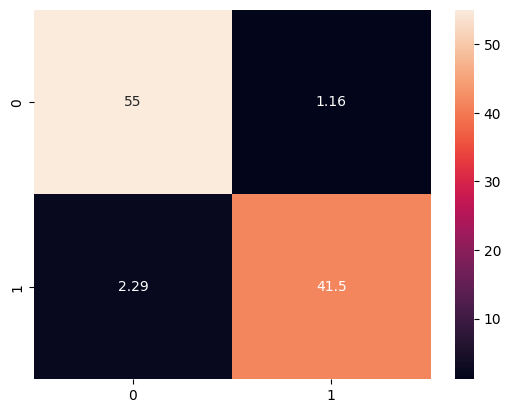

In [360]:
import seaborn as sns
sns.heatmap(metrics.confusion_matrix(y_test, y_pred_cat) / y_test.shape[0] * 100, annot=True, fmt='.3g')

In [ ]:
imp = cat.feature_importances_

array([ 1.95882108,  0.05299935,  7.24056434,  3.7423496 , 18.39187607,
        1.59357447, 25.36473663,  1.57407818,  1.49856335,  3.19628572,
        0.36924112,  7.40148296,  3.01245452,  2.83965986,  1.48213649,
        1.21792731,  3.64079751,  3.92579112,  2.87226253,  1.55456286,
        0.44570352,  0.83555539,  5.42005742,  0.23043581,  0.13808278])

In [376]:
imp = cat.feature_importances_
names = df_dum.drop('satisfaction', axis=1).columns
data = pd.DataFrame({'Название' : names, 'Важность' : imp}).sort_values('Важность', ascending=False)
data.head(10)

,Название,Важность
6,Inflight wifi service,25.364737
4,Type of Travel,18.391876
11,Online boarding,7.401483
2,Customer Type,7.240564
22,Class_Business,5.420057
17,Checkin service,3.925791
3,Age,3.742350
16,Baggage handling,3.640798
9,Gate location,3.196286
12,Seat comfort,3.012455


In [382]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\Frogs_MFCCs.csv')
df['target'] = df['Family'].apply(lambda x: 1 if x == 'Dendrobatidae' else 0)
df.drop(['Family', 'Genus',	'Species', 'RecordID'], axis=1, inplace=True)

In [383]:
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=31)

In [391]:
random_forest = RandomForestClassifier(n_estimators=10, random_state=31)
random_forest.fit(X_train, y_train)
y_pred1 = random_forest.predict(X_test)
print(metrics.classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1345
           1       1.00      0.94      0.97        94

    accuracy                           1.00      1439
   macro avg       1.00      0.97      0.98      1439
weighted avg       1.00      1.00      1.00      1439



In [385]:
from sklearn.neighbors import KNeighborsClassifier

In [386]:
KNN = KNeighborsClassifier(n_neighbors=11)
KNN.fit(X_train, y_train)
y_pred_KNN = KNN.predict(X_test)
print(metrics.classification_report(y_test, y_pred_KNN))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1345
           1       0.98      0.99      0.98        94

    accuracy                           1.00      1439
   macro avg       0.99      0.99      0.99      1439
weighted avg       1.00      1.00      1.00      1439



In [390]:
from sklearn.naive_bayes import GaussianNB
GNN = GaussianNB()
GNN.fit(X_train, y_train)
y_GNN = GNN.predict(X_test)
print(metrics.classification_report(y_test, y_GNN))

              precision    recall  f1-score   support

           0       1.00      0.81      0.90      1345
           1       0.27      1.00      0.43        94

    accuracy                           0.83      1439
   macro avg       0.64      0.91      0.66      1439
weighted avg       0.95      0.83      0.87      1439



In [392]:
from sklearn.ensemble import StackingClassifier
base_models = [('rf', random_forest), ('KNN', KNN), ('nb', GNN)]
meta = LogisticRegression()
stacking = StackingClassifier(base_models, meta, cv=5, n_jobs=-1)
stacking.fit(X_train, y_train)


,estimators,"[('rf', ...), ('KNN', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [393]:
y_pred2 = stacking.predict(X_test)
print(metrics.classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1345
           1       1.00      0.98      0.99        94

    accuracy                           1.00      1439
   macro avg       1.00      0.99      0.99      1439
weighted avg       1.00      1.00      1.00      1439

